# Problem Set 2


## An econometric analysis of Engel curves for U.S. households
In problem set 1, we undertook the initial analysis of the data and discussed regression models of Engel curves for food, clothes and alcohol. The objective of this week’s problem set is to estimate a simple regression model of the Engel curve using the OLS estimator.

The starting point is a regression model with one explanatory variable. Specifically, let us consider the case where the dependent variable represents food expenditures, while the explanatory variable is total expenditure:

\begin{align}
\text{xfath}_i = \beta_0 + \beta_1 \text{xtot}_i + u_i \tag{1}
\end{align}

In the consumption literature, it is common to use expenditure share, $\text{xfath}/\text{xtot}$, as the dependent variable instead of using total food expenditures. Furthermore, the logarithm of total expenditure deflated by an individual ”consumer price index” is often used as the explanatory variable. In this case, the regression model is:

\begin{align}
\frac{\text{xfath}_i}{\text{xtot}_i} = \delta_0 + \delta_1 \log \left(\frac{\text{xtot}_i}{\text{price}_i}
\right) + v_i \tag{2}
\end{align}


## Group work: Discuss model (2)

### Question 1
**Task:** What is the interpretation of $\delta_1$ when $%
\delta_1>0$ and $\delta_1<0$? 
(Hint: luxury versus necessity goods)

**Your answer:**

The share spent on food is explained by some delta0 and delta1. When delta1 > 0 the share spent on food rises as a percentage, so a luxury good, and when delta1 < 0 then a neccesarry good. 

### Question 2
**Task:** What is likely to be included in the error term in model (2)?
(Hint: What other variables may influence the dependent variable, $\text{xfath}/\text{xtot}$, besides the explanatory variable?)

**Your answer:**

Eating at other peoples house, getting food coupons from the government. 


## Python exercises

### Exercise 1: Estimate model (1)
In this exercise, we are going to estimate model (1) **for men only** using OLS:
\begin{align}
\text{xfath}_i = \beta_0 + \beta_1 \text{xtot}_i + u_i \tag{1}
\end{align}

To do this, revisit the lecture notebook and use the `statsmodels` approach described there.



---

**Task 1.** Load the data from PS2.dta

**Your code:**

In [13]:
import pandas as pd
import statsmodels.api as sm

data = pd.read_stata(r"PS2.dta")
data['const'] = 1

data.columns

Index(['year', 'province', 'hgy', 'hage', 'nety', 'xfath', 'xrest', 'xhhop',
       'xwcloth', 'xmcloth', 'xtran', 'xcare', 'xrecr', 'xtob', 'xalc',
       'pfath', 'prest', 'phhop', 'ptran', 'precr', 'ptob', 'palc', 'pwcloth',
       'pmcloth', 'dmale', 'down', 'dcity', 'dcar', 'dhlangf', 'dhlango',
       'dheduc', 'dhoccup', 'xcaruse', 'pcaruse', 'pcare', 'stonep', 'price',
       'rxtot', 'xtot', 'wfath', 'wwcloth', 'wmcloth', 'walc', 'const'],
      dtype='str')

**Task 2:** Estimate model (1) **for the male participants in the survey** only using the `statsmodels` module as described in lecture.

**Your code:**

In [19]:
# OLS estimation vha OLS fra statsmodels

getMales = data[data["dmale"] == 1]

model_sm = sm.OLS(getMales['xfath'], getMales[['const', 'xtot']]).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  xfath   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     13.11
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           0.000354
Time:                        15:45:35   Log-Likelihood:                -2157.0
No. Observations:                 258   AIC:                             4318.
Df Residuals:                     256   BIC:                             4325.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1443.0723    195.086      7.397      0.0


**Task 3:** What is the interpretation of the slope $\beta_1$ and intercept $\beta_0$ in model (1)? 


**Your answer:**

The average money spent on food when xtot is 0 is 1443 (weird!) and for each dollar spent in total the money spent on food at home goes up by 0.05 dollars. 

**Task 4:** What is the estimate of the slope? And the intercept?



**Your answer:**

0.05 and 1443

**Task 5:** What is the total variation in the dependent variable, SST? The explained variation in the dependent variable, SSE? The variation in the residuals, SSR?

_Hint:_ You can calculate these statistics manually using the code from the lecture. Alternatively, you can access the statistics directly as properties of your OLS results object `sm.OLS.fit()`. If you named this object `results`, you can access the SST using `results.centered_tss`, the SSR using `results.ssr` and the SSE using `results.ess`.

**Your code:**

In [28]:
SST = model_sm.centered_tss
SSR = model_sm.ssr
SSE = model_sm.ess

print("SST:",SST,", SSR:",SSR,", SSE: ", SSE)

R2 = (SSE / SST) 
print(R2)

SST: 290257414.4844961 , SSR: 276117266.3102634 , SSE:  14140148.174232721
0.04871588965038482


**Your answer:**

**Task 6:** Find the coefficient of determination, $R^2$. How can it be calculated from the three measures from the previous question? How would you interpret the calculated $R^2$?


**Your answer:**

**Task 7:** What is the estimate of the variance of the error term, $\hat \sigma^2$?

_Hint:_ use `results.mse_resid` to retrieve the estimated variance of the error term directly from the model object

**Your code:**

In [32]:
print(model_sm.mse_resid)

1078583.0715244664


**Your answer:**

### Exercise 2: Illustrate the estimated Engel curve

**Task 1:** Illustrate the estimated Engel curve in a graph together with a scatterplot of the actual data observations. 

_Hints:_ To plot the estimated Engel curve, you need the $\hat{y}$ values (your estimated xfath values) for each of the observed $x$-values (the xtot values) in the dataset. When plotted together, these $\hat{y}$ values form the line estimated by OLS.

If your OLS results object is called `results` and your observations of xtot are called `X`, you can extract the $\hat{y}$ values like this:

```py
y_hat = results.predict(X)
```

To do a lineplot in Seaborn, use the `sns.lineplot(x, y, data)` method.

To layer two plots on top of each other, simply execute two Seaborn commands after one another in a single cell.

**Your code:**

<Axes: xlabel='xtot', ylabel='None'>

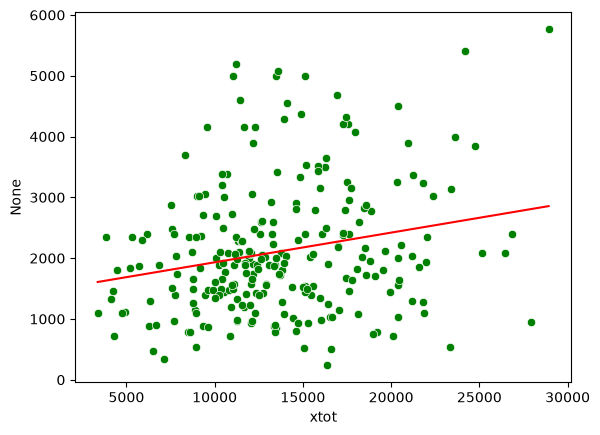

In [66]:
import seaborn as sns


y_hat = model_sm.predict(getMales[['const', 'xtot']])

sns.lineplot(x = getMales["xtot"],y = y_hat, data = getMales, color = "red")
sns.scatterplot(x = getMales["xtot"], y = getMales["xfath"], data = getMales, color = "green")



**Task 2:** Perform scatterplots of the residuals from the regression against xtot and the predicted value of food consumption, separately.What shall you expect given the assumptions presented in the lectures? Should you expect the total expediture to correlate with the residuals? 

_Hint:_
You can access the residuals using the `.resid` property of your results object.

_Pro tip:_ You can manually change the labels of the y- and x-axis of Seaborn plots by adding `.set(ylabel="Residuals", xlabel="xtot")` to the end of your plot command

**Your code:**

<Axes: xlabel='None', ylabel='xtot'>

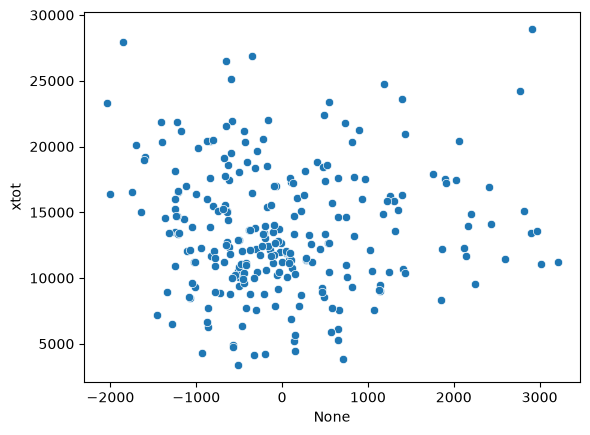

In [74]:
#Task 2a 
sns.scatterplot(x = model_sm.resid, y = getMales["xtot"])

<Axes: xlabel='None', ylabel='None'>

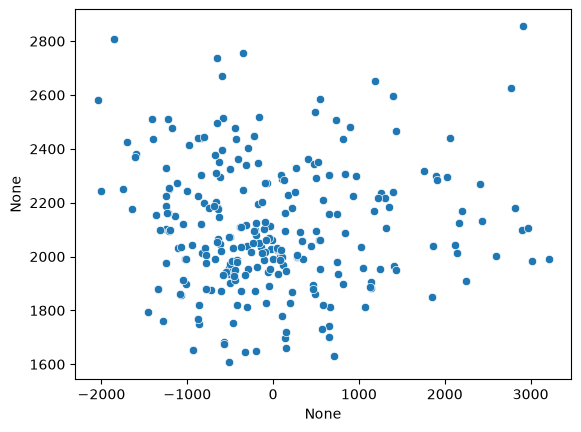

In [75]:
sns.scatterplot(x = model_sm.resid, y = y_hat)

Remember the mechanical properties of the OLS estimator: The residuals sum to zero, $E(u)=0$, and are always uncorrelated with the explanatory variables, $E(x|u)=0$

### Exercise 2: Estimate model (2)

In this exercise, we are going to estimate model (2) for men and women individually:
$$
\frac{\text{xfath}_i}{\text{xtot}_i} = \delta_0 + \delta_1 \log \left(\frac{\text{xtot}_i}{\text{price}_i}
\right) + v_i \tag{2}
$$


**Task 1:** Construct the variables needed to estimate model (2). 

_Hint:_ The $\text{price}_i$ variable is included in the dataset under the name `price`.


**Your code:**

In [79]:
getFemale = data[data["dmale"] == 0]
menXFath = getMales["xfath"]
menXTot = getMales["xtot"]
menPrice = getMales["price"]
womenXFath = getFemale["xfath"]
womenXTot = getFemale["xtot"]
womenPrice = getFemale["price"]


**Task 2:** Estimate model (2) by OLS for the budget shares of food, clothing and alcohol for men and women, separately. For each gender and each of the three expenditure categories, print the estimated slope parameters. 

_Hint_: Write a nested for-loop where you estimate the model and print the parameter estimate for each of the genders and and each of the three dependant variables. 

To access the individual model parameters, you can use the `.params` property of the results object. For example, if you have an explanatory variable called `log_xtot_adj`, you can access the parameter estimate like this:


```py
model = sm.OLS(y, X)
results = models.fit()
delta1 = results.params['log_xtot_adj']
```

**Your code:**

In [86]:
import numpy as np
for gender in [0,1]:
    for var in ["xfath","xtot","xcloth"]

model_sm = sm.OLS(getMales['xfath']/getMales["xtot"], np.log(getMales["xtot"]/getMales["price"]) ).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.714
Model:                            OLS   Adj. R-squared (uncentered):              0.713
Method:                 Least Squares   F-statistic:                              642.6
Date:                Tue, 08 Sep 2026   Prob (F-statistic):                    7.05e-72
Time:                        16:46:49   Log-Likelihood:                          216.45
No. Observations:                 258   AIC:                                     -430.9
Df Residuals:                     257   BIC:                                     -427.4
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0417      0.002     25.350      0.000       0.038       0.045
==============================================================================
Omnibus:                       58.245   Durbin-Watson:                   1.907
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              101.463
Skew:                           1.217   Prob(JB):                     9.28e-23
Kurtosis:                       4.874   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Task 3:** Interpret the estimation results in light of the discussion on luxury versus necessity goods (see group work). Which parameter is central to the analysis? What conclusions can be drawn on the basis of the analysis?

**Your answer:**

## Theoretical exercise
Solve the following theoretical exercises (using pen and paper). Estimated time for the exam is 30
minutes.

**Task 1:**
Write up the simple linear regression model (SLR) with a constant term and 1
explanatory variable in matrix form for $n$ observations.

**Task 2:** Write the OLS estimator in matrix form. Show that when one
calculates the OLS estimator, then: 
\begin{equation*}
\widehat{\beta }_{0}=\bar{y}-\frac{\sum_{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y%
})}{\sum_{i=1}^{n}(x_{i}-\bar{x})^{2}}\bar{x},\qquad \widehat{\beta }_{1}=%
\frac{\sum_{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})}{\sum_{i=1}^{n}(x_{i}-%
\bar{x})^{2}}
\end{equation*}%
where $\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_{i}$ and $\bar{y}=\frac{1}{n}%
\sum_{i=1}^{n}y_{i}$.

_Hints_: Use the following rule for inverting a matrix: 
\begin{equation*}
\left[ 
\begin{array}{cc}
a & b \\ 
c & d%
\end{array}%
\right] ^{-1}=\frac{1}{ad-bc}\left[ 
\begin{array}{cc}
d & -b \\ 
-c & a%
\end{array}%
\right]
\end{equation*}
as well rules (A.7) and (A.8) in Math Refresher A in the textbook.
